# 3. Feature Availability Analysis -- Logistic Regression

Can final academic outcome be predicted using information available at different stages of a student's progression?

Three predictor sets:
- **Day 1:** before any semester performance exists
- **After Semester 1:** semester 1 performance known
- **Full Data:** both semesters known

In [2]:
import sys
from pathlib import Path


cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.evaluate import evaluate_feature_set
from src.models import get_logistic_regression
from src.preprocessing import get_feature_availability_sets, load_data

sns.set_theme(style="whitegrid")
df = load_data()


## 3.1 Define feature sets

In [3]:
feature_sets = get_feature_availability_sets(df)

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} predictors")


Day 1: 24 predictors
After Semester 1: 30 predictors
Full Data: 36 predictors


## 3.2 Logistic Regression across feature sets

In [4]:
feature_results = [
    evaluate_feature_set(df, cols, name, get_logistic_regression(), scale_numeric=True)
    for name, cols in feature_sets.items()
]

feature_results_df = pd.DataFrame(feature_results)
display(feature_results_df.round(3))

# Save so 05_model_comparison.ipynb can load it without recomputing
feature_results_df.to_csv("../data/processed/logreg_feature_availability.csv", index=False)


,Feature Set,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall
0,Day 1,0.573,0.550,0.577,0.522,0.588
1,After Semester 1,0.698,0.658,0.683,0.560,0.758
2,Full Data,0.725,0.689,0.680,0.635,0.787


## 3.3 Visualize results
### 3.3.1 Macro F1 and accuracy

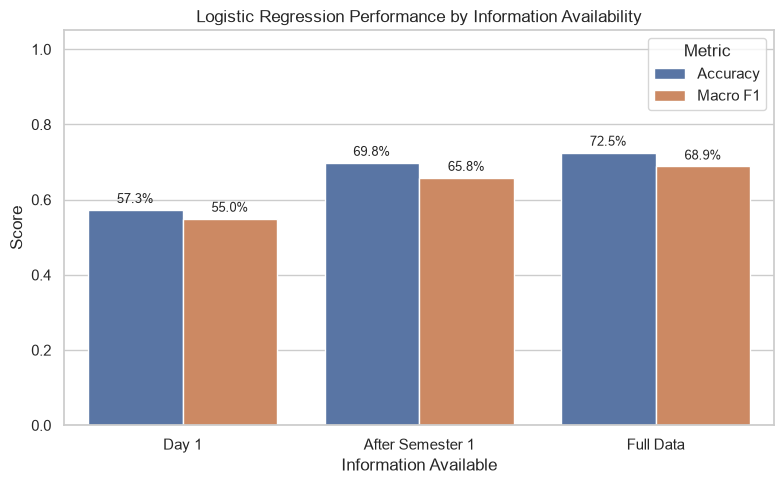

In [13]:
feature_performance_long = feature_results_df.melt(
    id_vars="Feature Set",
    value_vars=["Accuracy", "Macro F1"],
    var_name="Metric",
    value_name="Score"
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=feature_performance_long,
    x="Feature Set",
    y="Score",
    hue="Metric",
    ax=ax
)

# Give a little extra room for labels
ax.set_ylim(0, 1.05)

ax.set_title("Logistic Regression Performance by Information Availability")
ax.set_xlabel("Information Available")
ax.set_ylabel("Score")

# Add percentage labels above each bar
for container in ax.containers:
    labels = [
        f"{bar.get_height() * 100:.1f}%"
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "../reports/figures/logistic_performance_by_information.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3.3.2 Recall for each outcome

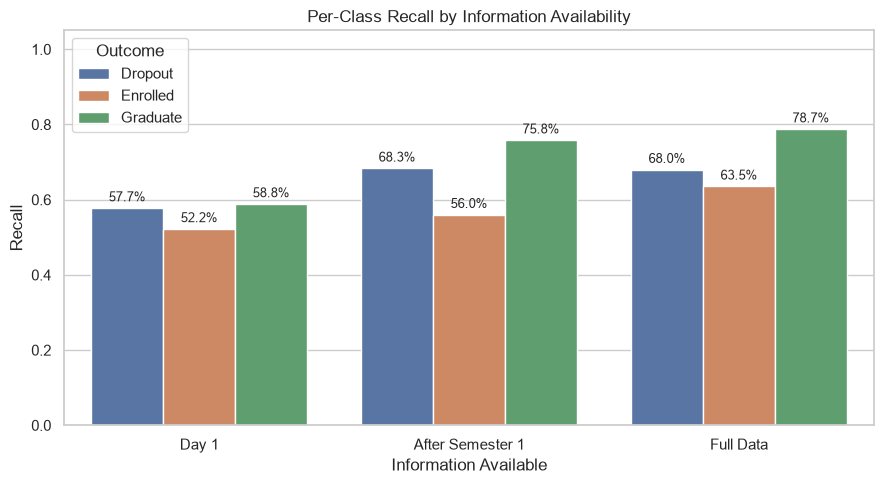

In [14]:
feature_recall_long = feature_results_df.melt(
    id_vars="Feature Set",
    value_vars=["Dropout Recall", "Enrolled Recall", "Graduate Recall"],
    var_name="Outcome",
    value_name="Recall"
)

feature_recall_long["Outcome"] = (
    feature_recall_long["Outcome"]
    .str.replace(" Recall", "", regex=False)
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=feature_recall_long,
    x="Feature Set",
    y="Recall",
    hue="Outcome",
    ax=ax
)

# Extra room above bars
ax.set_ylim(0, 1.05)

ax.set_title("Per-Class Recall by Information Availability")
ax.set_xlabel("Information Available")
ax.set_ylabel("Recall")

# Add percentage labels above each bar
for container in ax.containers:
    labels = [
        f"{bar.get_height() * 100:.1f}%"
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "../reports/figures/per_class_recall_by_information.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Conclusion:
Yes! We can predict the final academic outcome at every stage, and this one gets more accurate the longer we wait, but the value is anticipated.
- Early Predictive Power: Even on Day 1, before any grades, the model achieves 57.3% accuracy, surpassing both random guessing (33%) and majority-class guessing (50%). This early signal derives from demographic, admission, financial, and macroeconomic variables, though is limited in strength.
- Impact of Semester Data: The largest improvement occurs after receiving first-semester performance data, with accuracy jumping from 57.3% to 69.8% (+12.5 points). In contrast, moving from one semester to full data yields only a modest increase (+3.0 points to 72.8%), illustrating diminishing returns.
- Practical Implication: Institutions do not need to wait a full year to identify at-risk students; most predictive power is available after just one semester, enabling earlier intervention.
- Caveat on Class Imbalance: The "Enrolled" outcome remains the most challenging to predict at all stages (recall: 52.2% → 56.0% → 63.5%), reflecting underlying class imbalance (18% of students), rather than a model-specific limitation.